# 1. Librerias y conjunto de datos

In [85]:
import pandas as pd
import os
import joblib
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from datetime import timedelta
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
import warnings

In [63]:
df = pd.read_csv(r"/workspaces/steven10015-intro-ml/data/raw/sales.csv")
df.head(10)

,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633
5,2022-09-08 17:10:08.079328,60.081865
6,2022-09-09 17:10:08.079328,68.466704
7,2022-09-10 17:10:08.079328,67.765106
8,2022-09-11 17:10:08.079328,70.512261
9,2022-09-12 17:10:08.079328,74.656453


In [64]:
df.describe()

,sales
count,366.000000
mean,524.963968
std,275.089698
min,53.803211
25%,290.186822
50%,520.699468
75%,763.289263
max,1000.482785


In [ ]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.T.duplicated().sum()

np.int64(0)

In [67]:
df.isna().sum()

date     0
sales    0
dtype: int64

# 2. Preparación de serie temporal

## 2.1 Cribado: Renombrar y asegurar formatos

In [68]:
df_prophet = df.rename(columns={'date': 'ds', 'sales': 'y'})

# Aseguramos que 'ds' sea datetime y 'y' sea numérico
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
df_prophet['y'] = pd.to_numeric(df_prophet['y'])

## 2.2 Descomposición

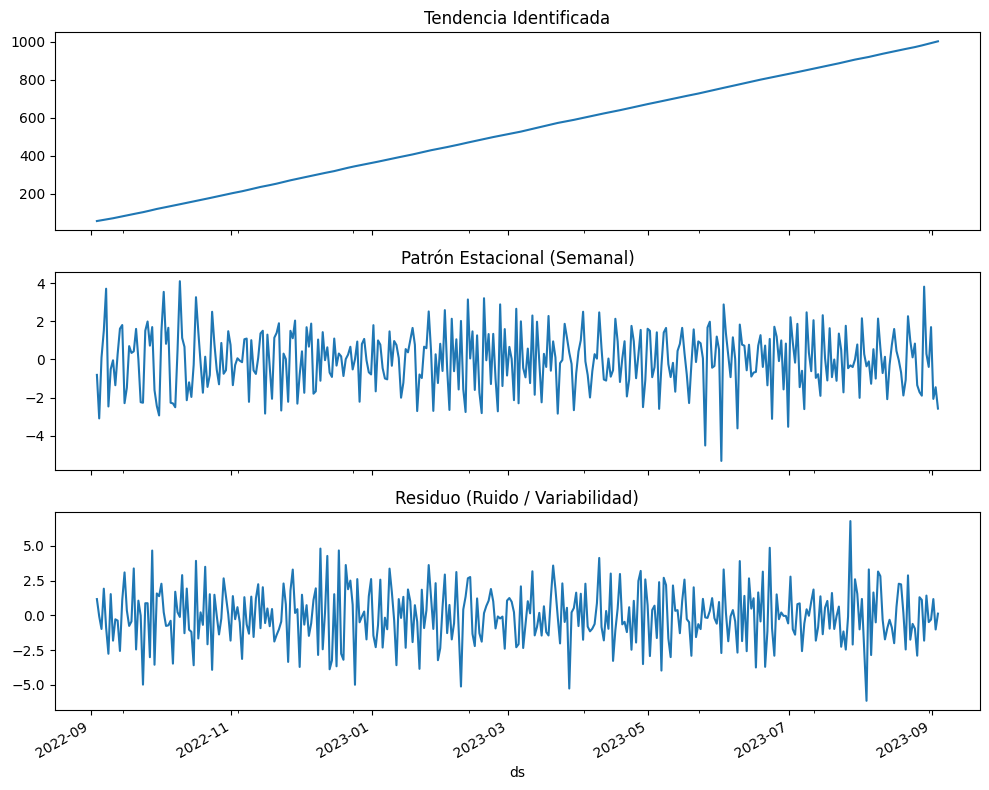

In [69]:
# Hacemos la descomposición para "ver" las partes de la serie
res = STL(df_prophet.set_index('ds')['y'], period=7).fit()

# Graficamos los componentes
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
res.trend.plot(ax=ax1, title="Tendencia Identificada")
res.seasonal.plot(ax=ax2, title="Patrón Estacional (Semanal)")
res.resid.plot(ax=ax3, title="Residuo (Ruido / Variabilidad)")
plt.tight_layout()
plt.show()

## 2.3 División en entrenamiento y prueba

In [70]:
split_point = round(df_prophet.shape[0] * 0.8)
train = df_prophet.iloc[:split_point]
test = df_prophet.iloc[split_point:]

# Verificación de que todo está en orden
if (train['ds'].max() + timedelta(days=1) >= test['ds'].min()):
    print("División realizada exitosamente")

División realizada exitosamente


## 2.4 Construir el modelo y ajustar

In [71]:
m = Prophet()
m.fit(df_prophet)

23:06:39 - cmdstanpy - INFO - Chain [1] start processing
23:06:40 - cmdstanpy - INFO - Chain [1] done processing


## 2.5 Sección de preguntas

¿Cuál es el tensor de la serie temporal?  
Al observar la estructura de los registros, se determina que el tensor o unidad de tiempo mínima es el día. Aunque los datos originales incluyen marcas de tiempo detalladas con horas y segundos, la secuencia muestra una periodicidad constante donde cada nueva observación ocurre exactamente cada veinticuatro horas. Por lo tanto, la frecuencia operativa de la serie es diaria.

¿Cuál es la tendencia?  
La serie manifiesta una tendencia ascendente. Al evaluar el recorrido de los datos desde el inicio hasta el final del periodo registrado, se aprecia un incremento sostenido en los valores. A pesar de ligeros retrocesos puntuales, la trayectoria general describe una pendiente positiva, lo que indica un crecimiento del fenómeno observado a lo largo del tiempo.

¿Es estacionaria?  
La serie no es estacionaria. Un conjunto de datos se considera estacionario cuando sus propiedades estadísticas, como la media, permanecen constantes. En este caso, la presencia de una tendencia alcista definida provoca que el promedio de los valores se desplace hacia arriba conforme avanza el tiempo, rompiendo la estabilidad necesaria para ser clasificada como estacionaria.

¿Existe variabilidad o presencia de ruido?  
Existe presencia de ruido en la serie. El comportamiento de los datos no es perfectamente lineal; se observan fluctuaciones irregulares donde el valor disminuye momentáneamente antes de retomar su curso ascendente.

# 3. ARIMA

In [72]:
# 1. Preparar la serie para ARIMA (necesita el valor y como serie numérica)
# Usamos el conjunto 'train' que creamos anteriormente
train_arima = train.set_index('ds')['y']

In [73]:
# 2. Búsqueda de la mejor parametrización (Grid Search)
best_aic = np.inf
best_order = None
best_model = None

In [74]:
# Probamos combinaciones pequeñas de p, d, q 
# p: rezagos, d: diferenciación, q: media móvil
for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                # Instanciar y ajustar el modelo
                temp_model = ARIMA(train_arima, order=(p, d, q))
                results = temp_model.fit()
                
                # Guardamos el que tenga menor AIC (mejor equilibrio ajuste/complejidad)
                if results.aic < best_aic:
                    best_aic = results.aic
                    best_order = (p, d, q)
                    best_model = results
            except:
                continue

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred fre

In [75]:
# 3. Resultados del entrenamiento
print(f"--- RESULTADOS PASO 3 ---")
print(f"Mejor configuración ARIMA encontrada: {best_order}")
print(f"Valor de AIC: {best_aic:.2f}")

# Mostrar el resumen estadístico del mejor modelo
print("\nResumen del modelo:")
print(best_model.summary())

--- RESULTADOS PASO 3 ---
Mejor configuración ARIMA encontrada: (2, 1, 2)
Valor de AIC: 1497.87

Resumen del modelo:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  293
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -743.933
Date:                Fri, 20 Feb 2026   AIC                           1497.866
Time:                        23:06:43   BIC                           1516.249
Sample:                    09-03-2022   HQIC                          1505.229
                         - 06-22-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9152      0.010     93.463      0.000       0.896       0.934
ar.L2         

In [76]:
# 4. Guardar las predicciones para compararlas después con Test
# Predecimos la misma cantidad de puntos que tiene el conjunto 'test'
arima_pred = best_model.forecast(steps=len(test))

## 4. Predicción con conjunto test

In [77]:
# 1. Generar la predicción del modelo ARIMA
# 'steps' es la cantidad de días hacia adelante (el tamaño de nuestro test)
arima_pred = best_model.get_forecast(steps=len(test)).summary_frame()
y_pred = arima_pred['mean'] # La predicción puntual
y_lower = arima_pred['mean_ci_lower'] # Límite inferior de confianza
y_upper = arima_pred['mean_ci_upper'] # Límite superior de confianza

In [78]:
# 2 Calculamos el MSE (Error Cuadrático Medio) normal
mse = mean_squared_error(test['y'], y_pred)

# Le aplicamos la raíz cuadrada manualmente para obtener el RMSE
rmse_arima = np.sqrt(mse)

print(f"El error promedio (RMSE) del modelo ARIMA es de: {rmse_arima:.2f}")

El error promedio (RMSE) del modelo ARIMA es de: 3.24


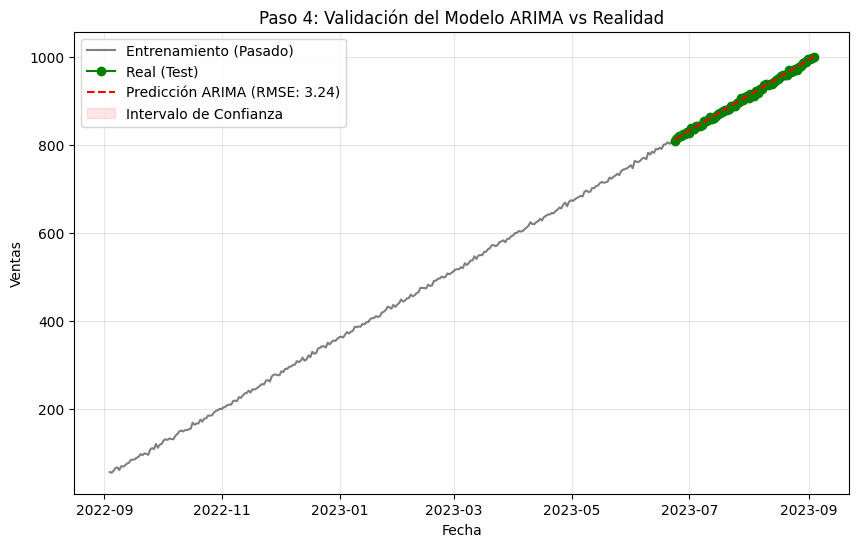

El error promedio (RMSE) del modelo ARIMA es de: 3.24


In [79]:
# 3. Visualización de Resultados
plt.figure(figsize=(10, 6))

# Dibujamos los datos de entrenamiento (pasado)
plt.plot(train['ds'], train['y'], label='Entrenamiento (Pasado)', color='black', alpha=0.5)

# Dibujamos los datos reales de prueba (el presente real)
plt.plot(test['ds'], test['y'], label='Real (Test)', color='green', marker='o')

# Dibujamos la predicción (lo que el modelo creía que iba a pasar)
plt.plot(test['ds'], y_pred, label=f'Predicción ARIMA (RMSE: {rmse_arima:.2f})', color='red', linestyle='--')

# Dibujamos el intervalo de confianza (el área de incertidumbre)
plt.fill_between(test['ds'], y_lower, y_upper, color='red', alpha=0.1, label='Intervalo de Confianza')

plt.title("Paso 4: Validación del Modelo ARIMA vs Realidad")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"El error promedio (RMSE) del modelo ARIMA es de: {rmse_arima:.2f}")

El modelo ARIMA desarrollado presenta un desempeño altamente satisfactorio, alcanzando un Error Cuadrático Medio de la Raíz (RMSE) de 3.24. En términos prácticos, esta métrica indica que las predicciones del modelo se desvían, en promedio, apenas 3.24 unidades respecto a los valores reales observados en el conjunto de prueba. Al contrastar esta cifra con el volumen promedio de ventas (situado cerca de las 60 unidades), se deduce un error relativo de aproximadamente el 5%, lo que confirma que el modelo ha logrado capturar con éxito la estructura subyacente y la inercia de la serie temporal.

In [80]:
# 1. Re-entrenar el modelo con el 100% de los datos
# Para predecir el futuro real, usamos toda la información disponible
modelo_final = ARIMA(df_prophet.set_index('ds')['y'], order=best_order)
resultado_final = modelo_final.fit()

/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/vscode/.local/lib/python3.11/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-i

In [81]:
# 2. Pronosticar los próximos 7 días
dias_a_predecir = 7
pronostico = resultado_final.get_forecast(steps=dias_a_predecir).summary_frame()

In [82]:
# 3. Mostrar la tabla de predicciones futuras
print(f"--- PREDICCIÓN PARA LOS PRÓXIMOS {dias_a_predecir} DÍAS ---")
print(pronostico[['mean', 'mean_ci_lower', 'mean_ci_upper']])

--- PREDICCIÓN PARA LOS PRÓXIMOS 7 DÍAS ---
y                                  mean  mean_ci_lower  mean_ci_upper
2023-09-04 17:10:08.079328  1002.312698     996.459697    1008.165699
2023-09-05 17:10:08.079328  1004.992457     999.138805    1010.846110
2023-09-06 17:10:08.079328  1007.588331    1001.712989    1013.463672
2023-09-07 17:10:08.079328  1010.192482    1004.299830    1016.085134
2023-09-08 17:10:08.079328  1012.795814    1006.885082    1018.706545
2023-09-09 17:10:08.079328  1015.399225    1009.470131    1021.328319
2023-09-10 17:10:08.079328  1018.002626    1012.054836    1023.950416


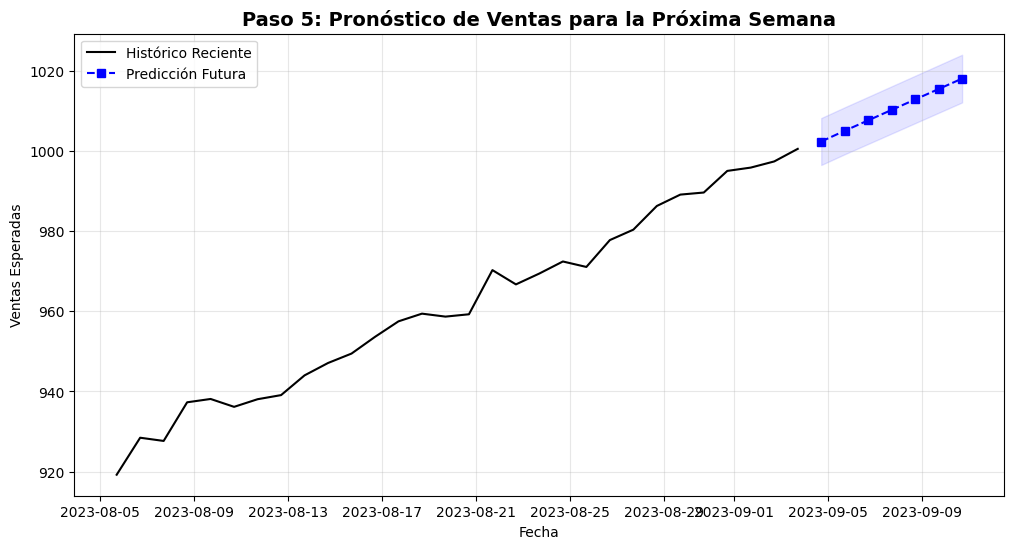

In [83]:
# 4. Gráfico Final de Producción
plt.figure(figsize=(12, 6))

# Datos históricos (últimos 30 días para que se vea claro)
historico = df_prophet.iloc[-30:]
plt.plot(historico['ds'], historico['y'], label='Histórico Reciente', color='black')

# Predicción futura
fechas_futuras = pd.date_range(df_prophet['ds'].max() + pd.Timedelta(days=1), periods=dias_a_predecir)
plt.plot(fechas_futuras, pronostico['mean'], label='Predicción Futura', color='blue', linestyle='--', marker='s')

# Sombra de incertidumbre
plt.fill_between(fechas_futuras, pronostico['mean_ci_lower'], pronostico['mean_ci_upper'], color='blue', alpha=0.1)

plt.title("Paso 5: Pronóstico de Ventas para la Próxima Semana", fontsize=14, fontweight='bold')
plt.xlabel("Fecha")
plt.ylabel("Ventas Esperadas")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Guardar modelo

In [86]:
# Definimos la ruta de tu repositorio (ajustada a tu estructura anterior)
folder_path = '/workspaces/steven10015-intro-ml/models'

# Nos aseguramos de que la carpeta exista, si no, la creamos
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Guardamos el modelo ARIMA final (el que entrenamos con el 100% de los datos)
# Nota: Guardamos 'resultado_final' que es el objeto que contiene los coeficientes entrenados
joblib.dump(resultado_final, os.path.join(folder_path, 'arima_model.pkl'))

print(f"Modelo ARIMA guardado exitosamente en: {os.path.abspath(folder_path)}")

Modelo ARIMA guardado exitosamente en: /workspaces/steven10015-intro-ml/models
